![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_4/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Analizando el Delito en Chicago

En este caso-taller vamos a utilizar datos geográficos y estimación de densidad de kernel para analizar delitos en Chicago. Esta ciudad es muy famosa no sólo por haber sido el hogar del mafioso Al Capone, sino también por sus altas tasas de delitos.

Para este taller obtuve datos del portal de la [ciudad de Chicago](https://www.chicago.gov/city/en/dataset/crime.html). La base de datos fue traducida y modificada para nuestras necesidades. Esta contiene todos los homicidios y robos que sucedieron entre el 1 de junio y el 31 de agosto de 2019.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

#### 1.1. Delitos

En la carpeta `data` se encuentra el archivo `Chicago_delitos_verano_2019.csv` cargue estos datos en su *cuaderno*. Describa brevemente el contenido de la base.

In [18]:
#Configuración del ambiente
import os
import pandas as pd
!pip install geopandas -q
import geopandas as gpd
!git clone https://github.com/camto-24/taller_4_Aprendizaje_no_supervisado.git
os.listdir("/content")
os.listdir("/content/taller_4_Aprendizaje_no_supervisado")

#Cargamos la base
ruta = "/content/taller_4_Aprendizaje_no_supervisado/data/Chicago_delitos_verano_2019.csv"
delitos = pd.read_csv(ruta, low_memory=False)
delitos.head()

fatal: destination path 'taller_4_Aprendizaje_no_supervisado' already exists and is not an empty directory.


,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01T05:07:00Z,homicidio,23,41.897950,-87.728625
1,2019-06-01T10:09:00Z,homicidio,71,41.753272,-87.648963
2,2019-06-01T12:46:00Z,homicidio,25,41.877622,-87.750728
3,2019-06-01T11:35:00Z,homicidio,16,41.960145,-87.699654
4,2019-06-02T09:39:00Z,homicidio,37,41.804773,-87.633256


In [17]:
# Tamaño de la base
print("Número de filas y columnas:", delitos.shape)

# Nombres de las columnas
print("\nColumnas disponibles:")
print(delitos.columns)

# Información general
print("\nInformación general:")
delitos.info()

# Valores nulos por columna
delitos.isnull().sum()

# Tipos de delitos más frecuentes
delitos["tipo_crimen"].value_counts().head(10)

# Lugares donde ocurren más delitos
delitos["nro_area_comunitaria"].value_counts().head(10)

#Tratamiento de la fecha
delitos["fecha"] = pd.to_datetime(delitos["fecha"], errors="coerce")
delitos["fecha"].min(), delitos["fecha"].max()

Número de filas y columnas: (17747, 5)

Columnas disponibles:
Index(['fecha', 'tipo_crimen', 'nro_area_comunitaria', 'lat', 'lon'], dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17747 entries, 0 to 17746
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 17747 non-null  object 
 1   tipo_crimen           17747 non-null  object 
 2   nro_area_comunitaria  17747 non-null  int64  
 3   lat                   17747 non-null  float64
 4   lon                   17747 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 693.4+ KB


(Timestamp('2019-06-01 05:00:00+0000', tz='UTC'),
 Timestamp('2019-09-01 04:48:00+0000', tz='UTC'))

La base de datos contiene 17.747 registros y 5 columnas. Cada fila representa un delito reportado en Chicago durante el periodo de análisis e incluye la fecha del delito, el tipo de crimen, el número del área comunitaria, y las coordenadas geográficas de latitud y longitud donde ocurrió el evento. Estas dos últimas variables son fundamentales para el análisis espacial, porque permiten ubicar cada delito en el mapa y construir posteriormente una estimación de densidad de kernel.

En la revisión inicial se encontró que la base no tiene valores nulos en ninguna de sus variables, lo cual facilita el análisis porque no es necesario eliminar registros por falta de información. También se observó que el tipo de delito más frecuente es el robo, con 17.603 ocurrencias, lo que representa casi la totalidad de los registros. Esto indica que la base está altamente concentrada en este tipo de crimen, por lo que el análisis espacial reflejará principalmente la distribución geográfica de los robos.

En cuanto a la variable de área comunitaria, el área con mayor número de delitos es la 32, seguida por las áreas 8 y 28. Esto sugiere que existen zonas específicas de la ciudad donde los reportes se concentran con mayor intensidad. Por esta razón, el uso de estimaciones de densidad de kernel resulta útil, ya que permite identificar visualmente los puntos calientes o zonas de mayor concentración delictiva en Chicago.



#### 1.2. Barrios de Chicago

También en la carpeta `data` se encuentran los archivos con los polígonos de las áreas comunitarias en un archivo comprimido llamado `Areas_comunitarias_Chicago.zip`. Genere un mapa interactivo con un popup con el nombre del area comunitaria.

In [39]:
# Configuración del entorno
import glob
import matplotlib.pyplot as plt
ruta_areas = "/content/taller_4_Aprendizaje_no_supervisado/data/Areas_comunitarias_Chicago.zip"

#Cargamos los datos
areas = gpd.read_file(f"zip://{ruta_areas}")
areas.head()


,area,area_num_1,area_numbe,comarea,comarea_id,community,perimeter,shape_area,shape_len,geometry
0,0.0,35,35,0.0,0.0,DOUGLAS,0.0,4.600462e+07,31027.054510,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,0.0,36,36,0.0,0.0,OAKLAND,0.0,1.691396e+07,19565.506153,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,0.0,37,37,0.0,0.0,FULLER PARK,0.0,1.991670e+07,25339.089750,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,0.0,38,38,0.0,0.0,GRAND BOULEVARD,0.0,4.849250e+07,28196.837157,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,0.0,39,39,0.0,0.0,KENWOOD,0.0,2.907174e+07,23325.167906,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


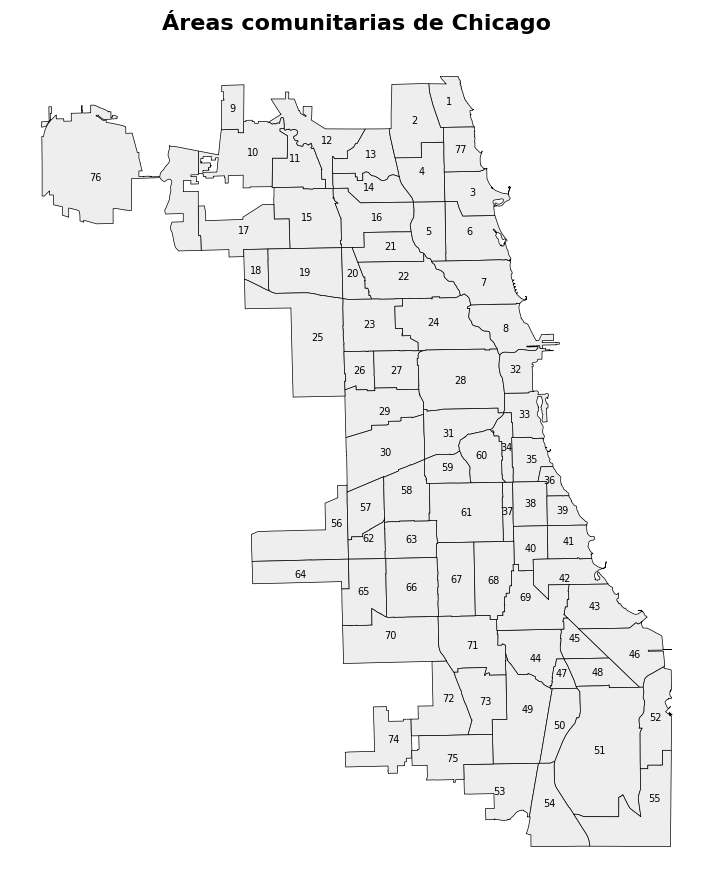

In [40]:
#Graficamos las áreas
fig, ax = plt.subplots(figsize=(11, 11))

areas.plot(
    ax=ax,
    color="#eeeeee",
    edgecolor="black",
    linewidth=0.5
)

# Agregar etiquetas en el centro de cada polígono
for idx, row in areas.iterrows():
    punto = row.geometry.representative_point()
    ax.text(
        punto.x,
        punto.y,
        str(row["area_numbe"]),
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title(
    "Áreas comunitarias de Chicago",
    fontsize=16,
    fontweight="bold"
)

ax.axis("off")

plt.show()

Además de la base de delitos, se cargó una representación geográfica con los polígonos de las áreas comunitarias de Chicago. Esta base tiene 77 filas y 10 columnas, donde cada fila corresponde a una de las áreas comunitarias de la ciudad. Dentro de sus variables se encuentra el número del área, el ID del área, el nombre de la comunidad y la columna geometry, que contiene los polígonos que delimitan espacialmente cada zona.

También se revisó el sistema de coordenadas de la capa geográfica, el cual corresponde a WGS84, un sistema de referencia geográfico en dos dimensiones. Esto significa que las ubicaciones están expresadas en coordenadas de latitud y longitud, lo cual es compatible con la base de delitos, que también contiene estas variables. Esta verificación es importante porque, para realizar análisis espaciales correctamente, tanto los puntos de delitos como los polígonos de las áreas comunitarias deben estar en el mismo sistema de coordenadas.

La visualización inicial de los polígonos permite observar la división territorial de Chicago en sus 77 áreas comunitarias. Esta capa será utilizada como base espacial para ubicar los delitos dentro de la ciudad.

### 2.   Análisis distribución del crimen por barrios

#### 2.1.  Genere una tabla descriptiva donde se muestra el número total de delitos, el número total de robos y el número total de homicidios, y como porcentaje de total por barrios. La tabla debe contener ademas una fila final donde se muestre el total para la ciudad. Describa los resultados que obtiene.


In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

#### 2.2. Genere una gráfica de dispersión entre el total de homicidios y robos por barrios. Incluya en la gráfica la recta de regresión que mejor ajusta a esos datos. Describa los resultados que obtiene.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3. Distribución espacial del delito

#### 3.1 Distribución respecto al centro de la ciudad

Tomando como centro de la ciudad las coordenadas (-87.627800, 41.881998), estime funciones de densidad que muestren gráficamente el gradiente del total de robos, y homicidios, como función de la distancia al centro de la ciudad. Explique cómo midió las distancias incluyendo que medida de distancia utilizó. Para elegir el ancho de banda y la función de kernel más apropiados utilice validación cruzada usando todas las opciones posibles de kernel. Describa los resultados que obtiene.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3.2 Puntos calientes en la ciudad

Usando `statsmodels` implemente la estimación de densidad bivariada para el total de robos y el total de homicidios. Muestre los resultados usando curvas de nivel en una visualización interactiva. Compare los resultados de estimar usando los anchos de banda: `normal_reference` y `cv_ml`. Explique en que consisten ambas formas de estimar el ancho de banda. Comente sobre los puntos calientes encontrados bajo ambos métodos y su ubicación en la ciudad. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

## 4. Explicando la ubicación del delito

El objetivo de este punto es encontrar posibles correlaciones  entre el crimen y características de la ciudad. Para ello, utilice los datos de OpenStreetMap y explore si existe una correlación entre el porcentaje del área de la comunidad  dedicado a tiendas (`retail`)  y comercios (`commercial`) y el número total de robos y homicidios en esa comunidad. Ofrezca una explicación intuitiva de por qué cree que aparecen estas correlaciones. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)